# Tehtävä 2: Aikasarjat ja aikasarjaennustaminen

Tämä tehtävä koostuu kahdesta osasta. Ensimmäinen osa liittyy aikasarjojen kuvailuun ja analysointiin, toinen osa aikasarjaennustamiseen.

## Osa 1: Aikasarjat

Tässä tehtävässä tarkastellaan kahden pörssiosakkeen kurssihistoriaa (vaihtoehtoisesti voi myös käyttää raaka-aineiden tai virtuaalivaluuttojen hintahistorioita). Näitä analysoidaan opituilla menetelmillä.

Osakkeiden kurssihistorioita ja raaka-aineiden/valuuttojen hintahistorioita saat Yahoo Finance -palvelusta.

### Tehtävä 1.1.

Tuo kahden osakkeen kurssihistoria käyttäen yfinance-kirjastoa. Voit valita osakkeet vapaasti ja voit käyttää myös esim. raaka-aineiden tai virtuaalivaluuttojen hintoja niin halutessasi. Älä kuitenkaan käytä samoja aineistoja kuin kurssin materiaaleissa tai luentoesimerkeissä. Historiatiedot pitää kuitenkin molemmille osakkeille löytyä vuoden 2020 alusta vuoden 2025 loppuun. Esitä kurssihistoriat viivakaavioiden avulla.

Vastaa sanallisesti seuraaviin kysymyksiin:

1. Miten kuvailisit valitsemiesi osakkeiden trendejä (nouseva, laskeva, vakaa)?

2. Kumpi osake on tällä aikavälillä pärjännyt paremmin? Perustele.


In [75]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

sns.set_style("whitegrid")

In [76]:
nvidia = yf.download("NVDA", start="2020-01-01", end="2025-12-31", auto_adjust=True)
kone = yf.download("KNEBV.HE", start="2020-01-01", end="2025-12-31", auto_adjust=True)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


<Axes: xlabel='Date'>

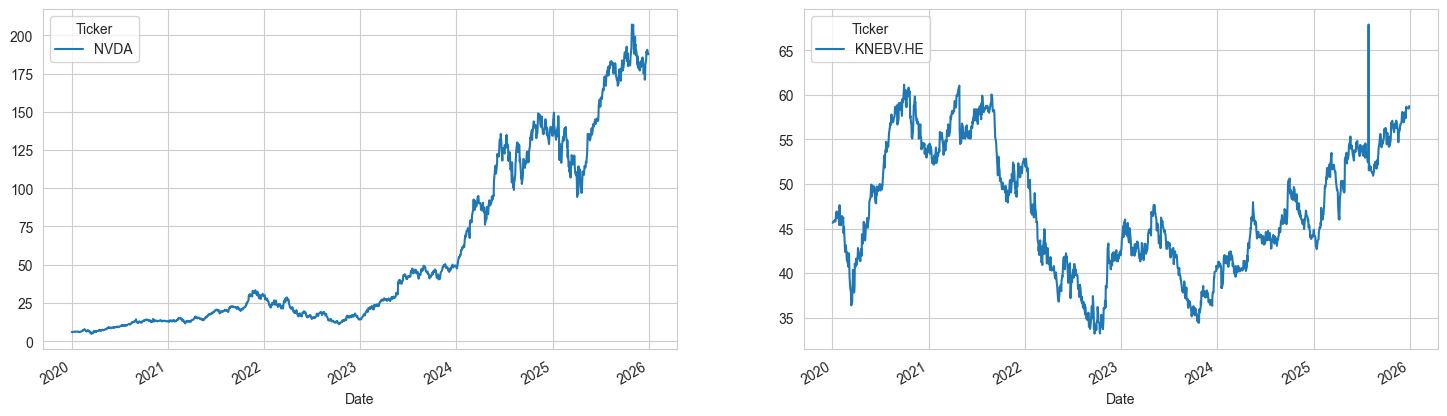

In [77]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(18,5))
nvidia['Close'].plot(ax=axs[0])
kone['Close'].plot(ax=axs[1])

1. Nvidian osakekurssi on ollut hyvin nouseva. Koneen osake on ollut myös kuuden vuoden tarkastelujaksolla nouseva.
2. Nvidian osake on pärjänny huomattavasti paremmin, sillä sen hinta tarkasteluvälillä on noussut tuhansia prosentteja, kun taas Koneen osake on noussut muutaman prosentin.

### Tehtävä 1.2

Muodosta kuva, joka koostuu kahdesta vierekkäin olevasta viivakaaviosta. Viivakaavioissa on kurssihistoriat vuodelta 2025.

<Axes: xlabel='Date'>

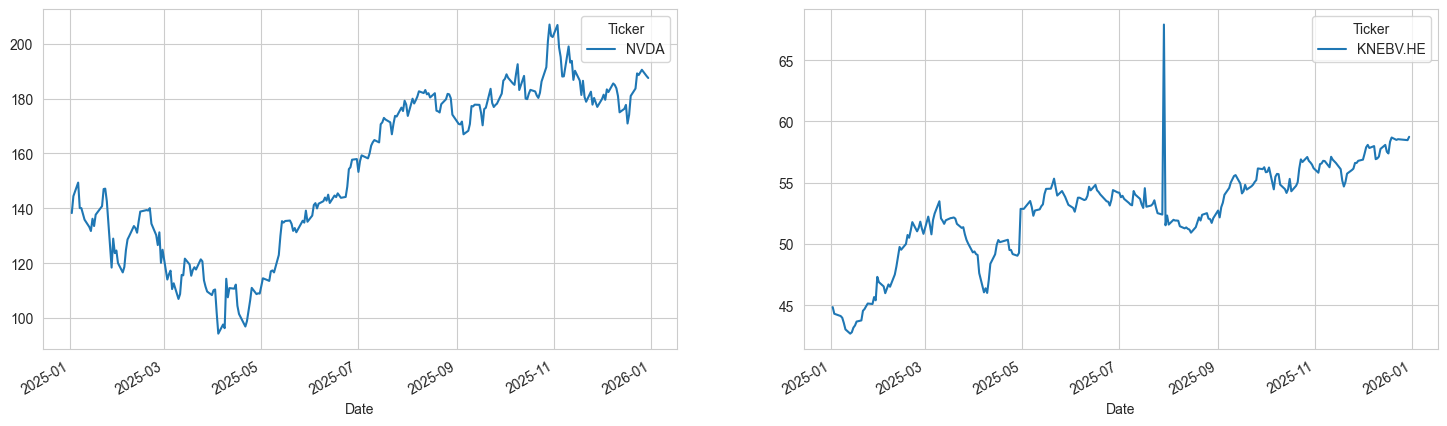

In [78]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(18,5))
nvidia['Close']["2025":"2025"].plot(ax=axs[0])
kone['Close']["2025":"2025"].plot(ax=axs[1])

### Tehtävä 1.3

Muodosta nyt kaksi vierekkäin olevaa viivakaaviota, joissa on laskettu osakkeiden vaihtomäärien kokonaissummat kuukausittain.

Vastaa sanallisesti seuraavaan kysymykseen: Milloin silmämääräisesti arvioiden näyttäisi olleen suurin vaihtomäärä osakkeissa? Kuinka paljon suunnilleen tällöin on osakkeita vaihdettu? (Silmämääräinen arvio riittää.)

<Axes: xlabel='Date'>

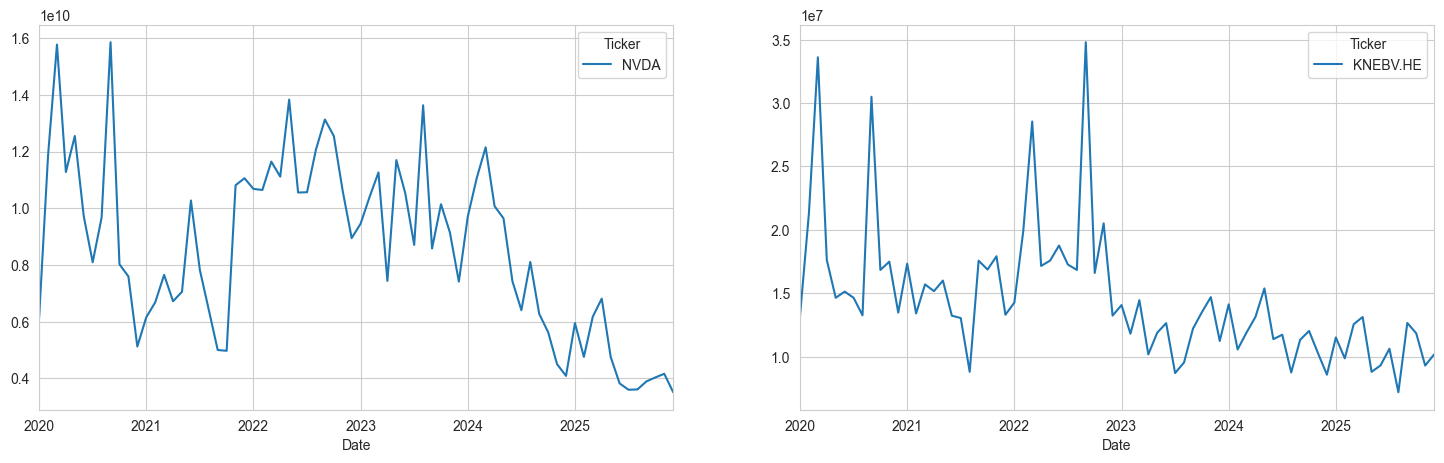

In [79]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(18,5))
nvidia['Volume'].resample("ME").sum().plot(ax=axs[0])
kone['Volume'].resample("ME").sum().plot(ax=axs[1])

Nvidiaa vaihdettiin eniten helmikuussa ja elokuussa 2020, jolloin vaihdettin noin 16 miljardia osaketta. Konetta vaihdettiin eniten syyskuussa 2022 35 miljoonalla osakkeella.

### Tehtävä 1.4

Valitse toinen osakkeista ja muodosta kuvaaja, jossa on alkuperäinen aikasarja, liukuva keskiarvo (40 päivää) ja liukuva keskiarvo (100 päivää) viivakaavioina. Kaikkien kolmen viivakaaviota pitäisi siis olla samassa kaaviossa.

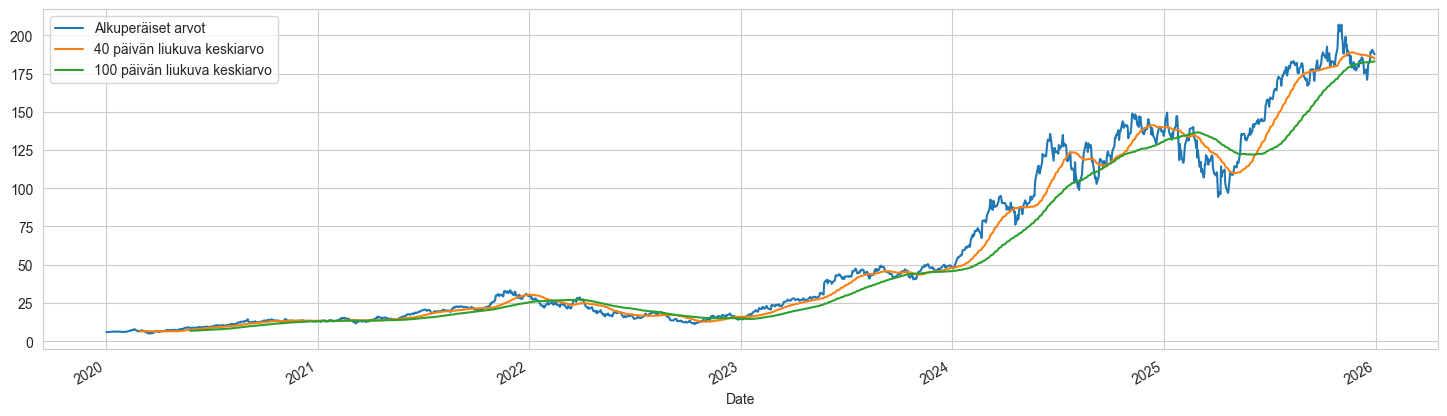

In [ ]:
fig, ax = plt.subplots(figsize=(18,5))

nvidia['Close'].plot(ax=ax)
nvidia['Close'].rolling(40).mean().plot(ax=ax)

# liukuva keskiarvo (200 päivää)
nvidia['Close'].rolling(100).mean().plot(ax=ax)

# selitelaatikko
plt.legend(['Alkuperäiset arvot' , '40 päivän liukuva keskiarvo' , '100 päivän liukuva keskiarvo'])

### Tehtävä 1.5

Lisää dataframeihin uudet sarakkeet osakkeiden päätöshintojen prosenttimuutoksille.

In [81]:
nvidia['nvidia_muutos%'] = nvidia['Close'].pct_change()*100
kone['kone_muutos%'] = kone['Close'].pct_change()*100

In [82]:
nvidia

Price,Close,High,Low,Open,Volume,nvidia_muutos%
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA,
Date,,,,,,
2020-01-02,5.970755,5.970755,5.891364,5.941885,237536000,NaN
2020-01-03,5.875187,5.918989,5.826158,5.851046,205384000,-1.600597
2020-01-06,5.899825,5.905051,5.755726,5.781858,262636000,0.419352
2020-01-07,5.971252,6.017045,5.883150,5.928197,314856000,1.210669
2020-01-08,5.982450,6.023764,5.926952,5.967020,277108000,0.187541
...,...,...,...,...,...,...
2025-12-23,189.199768,189.319757,182.890097,182.960100,174873600,3.005070
2025-12-24,188.599792,188.899779,186.579898,187.929831,65528500,-0.317112


In [83]:
kone

Price,Close,High,Low,Open,Volume,kone_muutos%
Ticker,KNEBV.HE,KNEBV.HE,KNEBV.HE,KNEBV.HE,KNEBV.HE,
Date,,,,,,
2020-01-02,45.636906,45.839807,45.293537,45.543260,382441,NaN
2020-01-03,45.730553,45.902238,45.293539,45.434009,432856,0.205200
2020-01-07,45.855415,46.308040,45.590084,45.730554,593010,0.273040
2020-01-08,45.824200,45.871021,45.527653,45.652514,359312,-0.068074
2020-01-09,45.917847,46.230002,45.746161,46.042708,519811,0.204361
...,...,...,...,...,...,...
2025-12-19,58.689224,58.728028,58.184787,58.184787,1095276,0.598601
2025-12-22,58.495209,58.805631,58.417605,58.689223,242791,-0.330581


### Tehtävä 1.6

Tarkastele prosenttimuutosten tilastollisia tunnuslukuja ja vastaa seuraaviin kysymyksiin:

1. Vertaa prosenttimuutosten keskiarvoja ja mediaaneja. Kummalla osakkeella keskimääräinen muutos on ollut suurempi?

2. Vertaa keskihajontoja. Kummalla osakkeella on ollut enemmän vaihtelua?

In [84]:
muutokset = pd.concat([nvidia["nvidia_muutos%"] , kone["kone_muutos%"]] , axis=1)
muutokset = muutokset.fillna(0)
muutokset.describe().round(2)

,nvidia_muutos%,kone_muutos%
count,1549.00,1549.00
mean,0.28,0.03
std,3.30,1.76
min,-18.45,-24.11
25%,-1.50,-0.81
50%,0.24,0.00
75%,2.12,0.80
max,24.37,29.58


1. Keskiarvojen perusteella Nvidia on noussut 0,28% per päivä ja Kone 0,03% per päivä. Nvidian prosenttimuutoksen mediaani on 0,28% ja Koneen 0,00%. Näiden perusteella Nvidian keskimääräinen muutos on ollut suurempi.
2. Nvidia: 3,30. Kone: 1,76. Nvidialla on ollut enemmän hajontaa keskimäärin, vaikka Koneella on suuremmat maksimi- ja minimarvot

### Tehtävä 1.7

Laske osakkeiden prosenttimuutosten korrelaatiokertoimen arvo. Kuvaile korrelaatiota: onko se positiivinen, negatiivinen vai hyvin heikko? Mitä tämä käytännössä tarkoittaa näiden osakkeiden suhteesta?

In [85]:
muutokset.corr()

,nvidia_muutos%,kone_muutos%
nvidia_muutos%,1.000000,0.121917
kone_muutos%,0.121917,1.000000


Osakkeiden prosenttimuutosten välinen korrelaatiokerroin on 0,12 joka tarkoittaa sitä, että korrelaatio on positiivinen, mutta hyvin heikko. Käytännössä se tarkoittaa sitä, että niiden liikkeiden välillä ei juurikaan ole mitään yhteyttä, eli osakkeiden välillä ei ole suhdetta. Tämä voi johtua mm. markkinoiden ja markkinapaikkojen erosta, sekä kokoluokan erosta. Sijoitusmielessä matala korrelaatio tarkoittaa, että nämä osakkeet tarjoavat hyvän hajautuksen.

### Tehtävä 1.8

Muodosta kuvaaja, jossa on osakkeiden liukuva korrelaatio. Kuvaile sitä: Onko osakkeiden suhde muuttunut ajan kuluessa? Jos on, niin miten? Osaatko sanoa, mikä tähän voisi olla syynä?

<Axes: xlabel='Date'>

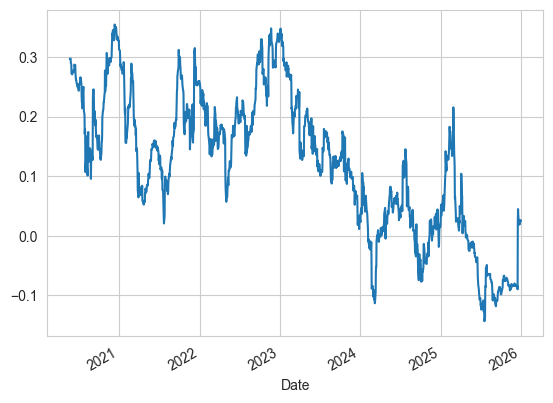

In [86]:
muutokset['nvidia_muutos%'].rolling(100).corr(muutokset['kone_muutos%']).plot()

Korrelaatiokerroin on viidessä vuodessa laskenut, mutta pääsääntoisesti pysynyt aina välillä 0-0,30. Korrelaation lasku saattaa johtua Nvidian osakkeen suuresta noususta vuodesta 2023 verrattuna Koneen vaihtelevaan osakkeeseen.

## Osa 2: Aikasarjaennustaminen

Valitse jokin seuraavista aineistoista:
* hiilidioksidin määrä ilmakehässä
* lento (Airpassengers.csv, löytyy datapaketista)
* oluen tuotantomääriä (beer.csv, löytyy datapaketista)
* sähkön tuotantoa (Electric_Production.csv, löytyy datapaketista)

Alla olevissa soluissa on koodi, joilla saat tuotua aineiston oikeassa muodossa. Voit poistaa ne solut, joita et käytä.

In [87]:
# HIILIDIOKSIN MÄÄRÄ ILMAKEHÄSSÄ
df_co2 = pd.read_csv('https://www.esrl.noaa.gov/gmd/webdata/ccgg/trends/co2/co2_mm_mlo.txt', sep=r'\s+', skiprows=42, usecols=[0, 1, 3], names=['year', 'month', 'average'])
df_co2.index = pd.to_datetime(df_co2['year'].astype(str)+df_co2['month'].astype(str), format='%Y%m')
df_co2 = df_co2.drop(['year', 'month'], axis=1)
df_co2

,average
1958-03-01,315.71
1958-04-01,317.45
1958-05-01,317.51
1958-06-01,317.27
1958-07-01,315.87
...,...
2025-10-01,424.87
2025-11-01,426.46
2025-12-01,427.49
2026-01-01,428.62


In [88]:
# Lentomatkustajien lukumääriä (löytyy datapaketista)
# df=pd.read_csv('AirPassengers.csv')
# df.index=pd.to_datetime(df['Month'],format='%Y-%m')
# df=df.drop('Month',axis=1)
# df.head()

In [89]:
# Oluen tuotantomääriä beer.csv (löytyy data-paketista)
# Lähde: https://www.kaggle.com/shenba/time-series-datasets

# df=pd.read_csv('beer.csv')
# df.index=pd.to_datetime(df['Month'],format='%Y-%m')
# df=df.drop('Month',axis=1)
# df.head()

In [90]:
# Sähkön tuotantoa Electric_Production.csv (löytyy data-paketista)
# Lähde: https://www.kaggle.com/shenba/time-series-datasets

# df=pd.read_csv('Electric_Production.csv')
# df.index=pd.to_datetime(df['DATE'],format='%m/%d/%Y')
# df=df.drop('DATE',axis=1)
# df.head()

### Tehtävä 2.1

Muodosta viivakaavio, jossa näkyy aikasarja koko siltä ajalta kuin se on aineistossa.

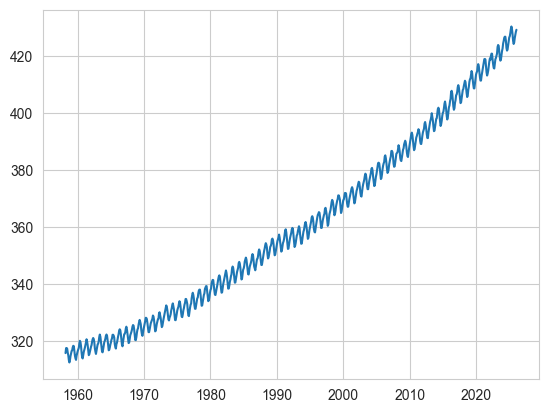

In [91]:
plt.plot(df_co2.index, df_co2["average"])

### Tehtävä 2.2

Tarkastele visuaalisesti aikasarjan komponentteja muodostamalla kaavio, jossa komponentit on eroteltu. Vastaa sanallisesti seuraaviin kysymyksiin:
* Onko aineistossa kausivaihtelua? Mikäli on, mikä kauden pituus on?
* Onko aineistossa trendi? Mikäli on, millainen?

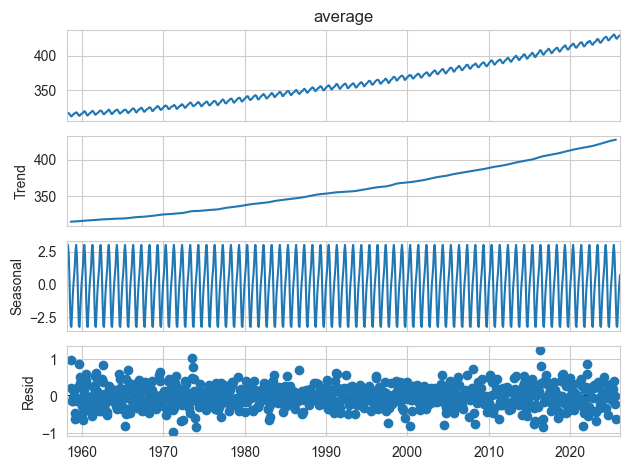

In [92]:
from statsmodels.tsa.api import seasonal_decompose, ExponentialSmoothing

seasonal_decompose(df_co2["average"]).plot()
plt.show()

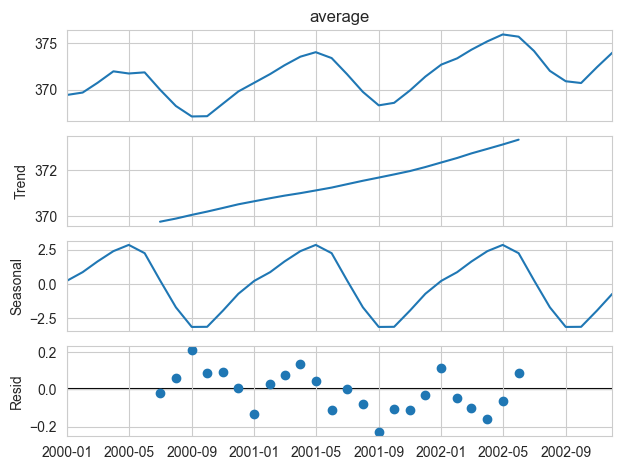

In [ ]:
# Lyhyempi tarkastelujakso helpompaan tarkasteluun
seasonal_decompose(df_co2["average"]["2000":"2002"]).plot()
plt.show()

1. Aineistossa on kausivaihtelua ja yhden kauden pituus on 12 kuukautta. Hiilidioksidin määrä nousee loka-toukokuu ja laskee touko-syyskuu.
2. Aikasarjan trendi on selvä kasvava.

### Tehtävä 2.3

Sovita aineistoon sopiva eksponentiaalisen tasoituksen malli. Perustele sanallisesti, miksi valitsit kyseisen arvon seuraaville parametreille:

* seasonal
* seasonal_periods
* freq

In [94]:
malli = ExponentialSmoothing(df_co2['average'], trend='add', seasonal='add', seasonal_periods=12, freq="MS").fit()

In [95]:
df_co2['Ennuste'] = malli.fittedvalues
df_co2.head()

,average,Ennuste
1958-03-01,315.71,315.887458
1958-04-01,317.45,316.955610
1958-05-01,317.51,317.713124
1958-06-01,317.27,317.117840
1958-07-01,315.87,315.840770


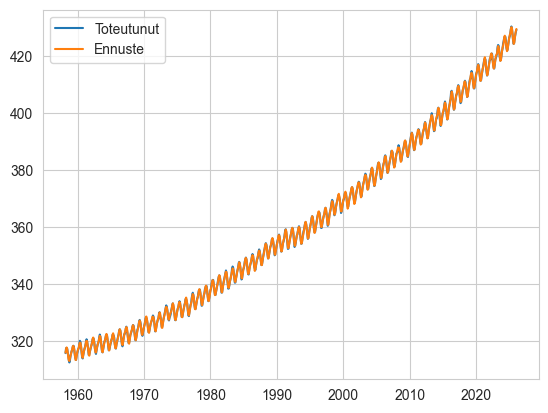

In [96]:
plt.plot(df_co2.index, df_co2['average'], label='Toteutunut')
plt.plot(df_co2.index, df_co2['Ennuste'], label='Ennuste')
plt.legend()

1. Valitsin seasonal parametrin arvoksi "add", sillä kausivaihtelun suuruus pysyy aina lähes samana. Tämä nähtiin seasonal komponentista edellisessä tehtävässä.
2. Valitsin seasonal_frequency parametrin arvoksi 12, sillä aineistossa jakso kestää yhden vuoden. Arvot ilmaistaan kuukausittain. Vuodessa on 12 kuukautta, joten jaksossa on 12 arvoa.
3. Valitsin freq parametrin arvoksi "MS", sillä aineistossa arvot ilmaistaan aina kuukausittain kyseisen kuukauden alussa eli "Month Start"

### Tehtävä 2.4

Tarkastele sovittamasi mallin virhettä. Muodosta kolme kaaviota ja tulkitse kukin niistä:

* Histogrammi virheistä
* Hajontakuvio, joka vertaa ennusteita toteutuneisiin arvoihin
* Hajontakuvio, joka vertaa toteutuneita arvoja ennustevirheisiin


In [97]:
df_co2['Ennustevirhe'] = malli.resid
df_co2.head()

,average,Ennuste,Ennustevirhe
1958-03-01,315.71,315.887458,-0.177458
1958-04-01,317.45,316.955610,0.494390
1958-05-01,317.51,317.713124,-0.203124
1958-06-01,317.27,317.117840,0.152160
1958-07-01,315.87,315.840770,0.029230


<Axes: xlabel='Ennustevirhe', ylabel='Count'>

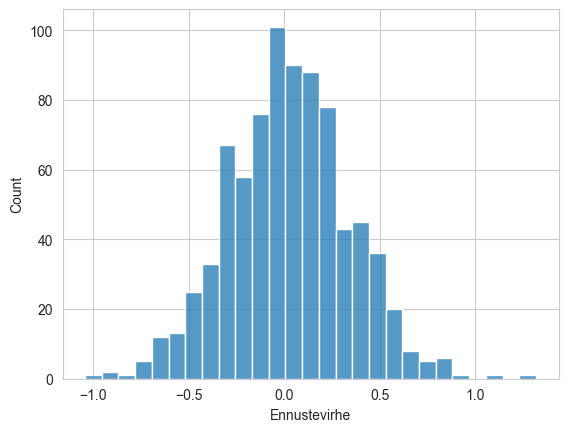

In [ ]:
# Histogrammi virhejakaumasta
sns.histplot(data=df_co2, x="Ennustevirhe")

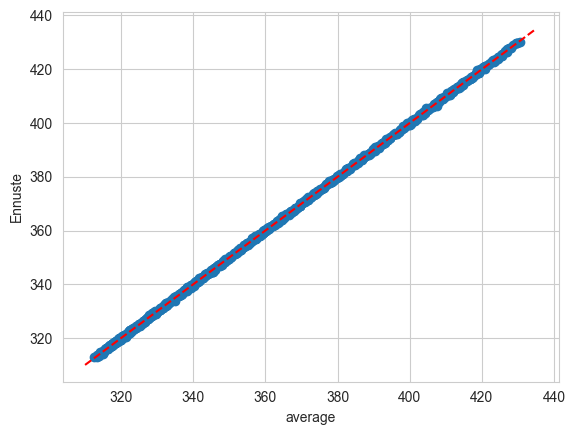

In [107]:
# Hajontakuvio, jossa verrataan ennusteita toteutuneisiin arvoihin
plt.scatter(df_co2['average'] , df_co2['Ennuste'])
plt.xlabel('average')
plt.ylabel('Ennuste')
plt.plot([310, 435] , [310, 435], 'r--')

Text(0, 0.5, 'Ennustevirhe')

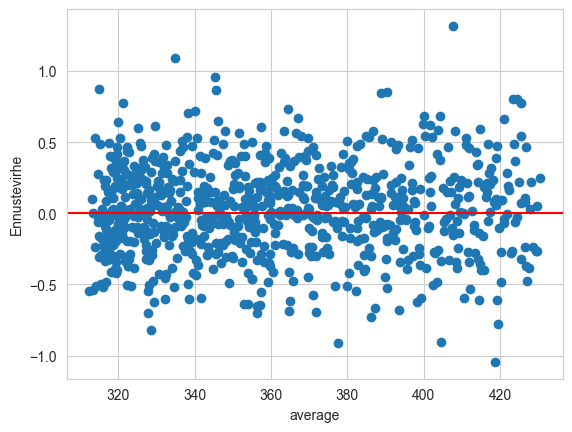

In [108]:
# verrataan toteutuneita arvoja ja virhettä
plt.scatter(df_co2['average'] , df_co2['Ennustevirhe'])
plt.axhline(color='red')
plt.xlabel('average')
plt.ylabel('Ennustevirhe')

1. Histogrammi: Kuvattu virheiden jakauma on suhteellisen symmetrinen ja keskittyy lähelle nollaa, joiden perusteella ennustusmalli näyttäisi toimivan hyvin.
2. Hajontakuvio 1: Ennusteet ja toteutuneet arvot seuraavat lähes täydellisesti suoraa y=x ilman selkeitä virheitä, joka kertoo myös hyvästä mallista.
3. Hajontakuvio 2: Ennustevirhe toteutunutta arvoa kohden näyttää satunnaiselta. Jos kaaviota tutkii tarkasti, niin malli näyttäisi ennustavan hieman paremmin pienempiä arvoja kuin suuria, mutta mielestäni tämä ero ei ole merkittävä.

### Tehtävä 2.5

Käytä nyt muodostamaasi mallia ennustamiseen. Muodosta ennuste seuraaville viidelle vuodelle ja tee kaavio, jossa näkyy sekä toteutuneet arvot, että ennusteesi. Vastaa sanallisesti seuraavaan kysymykseen: Vaikuttaako ennuste uskottavalta? Miksi tai miksi ei?

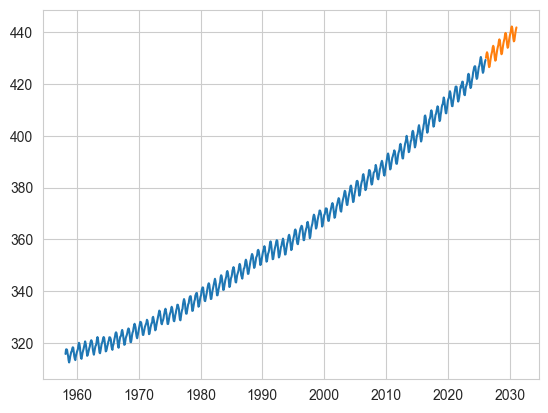

In [117]:
ennusteet = malli.forecast(60).to_frame(name='Ennuste')
plt.plot(df_co2.index, df_co2['average'])
plt.plot(ennusteet.index, ennusteet['Ennuste'])

Ennuste näyttää uskottavalta, sillä ennuste seuraa uskottavasti aineiston nousevaa trendiä, sekä kausivaihtelu pysyy samana vaihteluajan ja vaihteluvälin puolesta.